In [16]:
import matplotlib.pyplot as plt
import sympy as sp
from sympy import symbols, I, Abs, re, im
from sympy.physics.control import *
import numpy as np
import matplotlib.pyplot as plt

# Funções Auxiliares

In [3]:
s, k = sp.symbols('s k')
ganho = k

## Função para receber coeficientes e transformar em polinômio

In [5]:
def polinomio(entrada):
    coeficientes = entrada.strip().split()  # Transforma a entrada em uma lista de strings e remove espaços extras
    coeficientes.reverse() # Inverte a lista
    lista_polinomio = []
    
    # Percorre de trás para frente para começar pelo maior expoente
    for exp in range(len(coeficientes) - 1, -1, -1):
        coef = coeficientes[exp]
        
        # Pula coeficientes que são zero
        if coef == "0":
            continue
            
        # Formata o termo dependendo do expoente
        if exp > 1:
            termo = f"{coef}*s**{exp}"
        elif exp == 1:
            termo = f"{coef}*s"
        else:
            termo = f"{coef}"
            
        lista_polinomio.append(termo)
        
    return " + ".join(lista_polinomio)


## Função para calcular passo 4

In [43]:
def lgr_real(polos, zeros):
    # Manter apenas polos e zeros reais
    for polo in polos:
        if(im(polo) != 0):
            polos.pop(polo)
    for zero in zeros:
        if(im(zero) != 0):
            zeros.pop(zero)

## Função para passo 07

In [40]:
def plot_assintotas(ax, ponto, angulos, comprimento=10):
    x0, y0 = ponto

    for angulo in angulos:
        theta = np.radians(angulo)

        x1 = x0 + comprimento * np.cos(theta)
        y1 = y0 + comprimento * np.sin(theta)

        ax.plot([x0, x1], [y0, y1], linestyle='--')

    ax.scatter(x0, y0, color='black', zorder=3, label = "sigma")
    ax.legend()


# Passo a passo LGR

In [15]:
print("Forneça os coeficientes da função G(s)...")
numerador_G = polinomio(input("Digite os coeficientes do numerador: "))
denominador_G = polinomio(input("Digite os coeficientes do denominador: "))

numerador_G = sp.parse_expr(numerador_G, local_dict={'s': s})
denominador_G = sp.parse_expr(denominador_G, local_dict={'s': s})

G = TransferFunction(numerador_G, denominador_G, s)
G

Forneça os coeficientes da função G(s)...


TransferFunction(1, s**4 + 12*s**3 + 64*s**2 + 128*s, s)

In [7]:
print("Forneça os coeficientes da função H(s)...")
numerador_H = polinomio(input("Digite os coeficientes do numerador: "))
denominador_H = polinomio(input("Digite os coeficientes do denominador: "))

numerador_H = sp.parse_expr(numerador_H, local_dict={'s': s})
denominador_H = sp.parse_expr(denominador_H, local_dict={'s': s})

H = TransferFunction(numerador_H, denominador_H, s)
H

Forneça os coeficientes da função H(s)...


TransferFunction(1, 1, s)

In [8]:
ft = Series(G, H).doit()
ft

TransferFunction(1, s**4 + 12*s**3 + 64*s**2 + 128*s, s)

## Passo 01 - Escrever polinômio característico

In [9]:
print("1 + K*")
ft

1 + K*


TransferFunction(1, s**4 + 12*s**3 + 64*s**2 + 128*s, s)

## Passo 02 = Fatorar polinômio - NÂO FATORA POLO COMPLEXO

In [10]:
fatorado = sp.factor(ft)
print("1 + K*")
fatorado

1 + K*


TransferFunction(1, s*(s + 4)*(s**2 + 8*s + 32), s)

# Passo 3 - Polos e Zeros de malha aberta

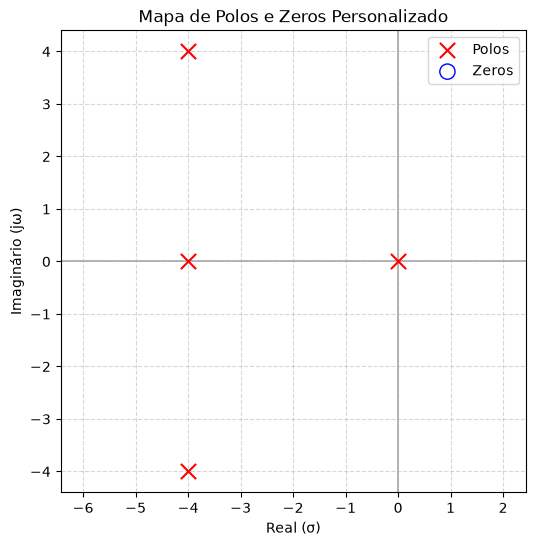

In [28]:
# 1. Extrai as coordenadas numéricas reais e imaginárias do SymPy
zeros, polos = pole_zero_numerical_data(fatorado)

def grafico_base():
    # 2. Cria o gráfico nativo no Matplotlib
    fig, ax = plt.subplots(figsize=(6, 6)) # Modificar limites 

    # Desenha os Polos (X vermelho) e Zeros (O azul)
    ax.scatter([p.real for p in polos], [p.imag for p in polos], 
            marker='x', color='red', s=120, label='Polos', zorder=3)
    ax.scatter([z.real for z in zeros], [z.imag for z in zeros], 
            marker='o', color='blue', facecolors='none', s=120, label='Zeros', zorder=3)

    ax.axhline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Real
    ax.axvline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Imaginário

    # Configurações visuais finais do gráfico
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel('Real (σ)')
    ax.set_ylabel('Imaginário (jω)')
    ax.set_title('Mapa de Polos e Zeros Personalizado')
    ax.axis('equal') # Garante proporção 1:1 perfeita no plano complexo
    ax.legend()
    return ax


grafico_base()
plt.show()

## Passo 04 - Assinalar segmentos do eixo real LGR

In [ ]:
def lgr_real(polos, zeros):
    # Manter apenas polos e zeros reais
    polos_reais = [polo for polo in polos if polo.imag == 0]
    zeros_reais = [zero for zero in zeros if zero.imag == 0]

    polos_zeros = polos_reais + zeros_reais
    polos_zeros.sort(reverse=True)
    i = 1
    linhas = []
    for ponto in polos_zeros:
        if(i % 2 == 1):
            inicio = ponto
        else:
            final = ponto
            linhas.append([inicio, final])
        i+=1
    return linhas
lgr_real(polos, zeros)

[0.0, -4.0]


[[0.0, -4.0]]

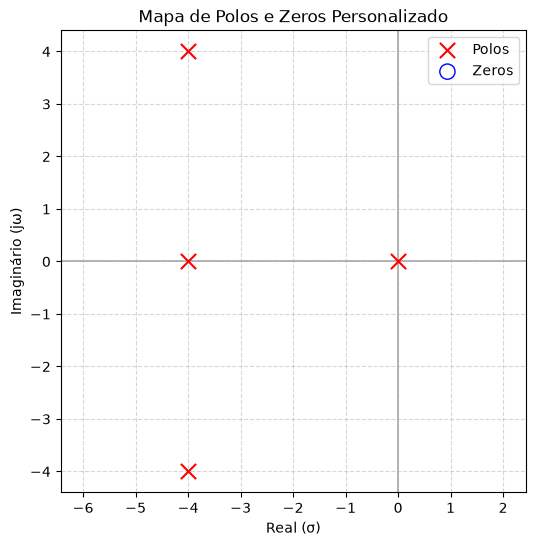

In [27]:
grafico_base()

plt.show()

## Passo 05 - Determinar número de lugares separados

In [13]:
n_polos = len(polos)
n_zeros = len(zeros)
if(n_polos >= n_zeros):
    ls = n_polos
else:
    ls = n_zeros
print(f"O número de lugares separados é {ls}")

O número de lugares separados é 4


## Passo 06 - LGR é simétrico em relação ao eixo real

## Passo 07 - Número de seguimentos LGR em direção a zeros infinitos

In [17]:
print(polos)

[-4.0, 0.0, (-4-4j), (-4+4j)]


In [24]:
n_assintotas = n_polos - n_zeros

# Cálculo de sigma
soma_real = 0
for polo in polos:
    parte_real = re(polo)
    soma_real += parte_real
for zero in zeros:
    parte_real = re(zero)
    soma_real -= parte_real

sigma = soma_real/(n_polos - n_zeros)

#Cálculo do angulo das assintotas
angulos_assintotas = []
for q in range(n_polos - n_zeros): # 0, 1, 2, ..., (np - nz- 1)
    phi = (2*q + 1) *180/(n_polos - n_zeros)
    angulos_assintotas.append(phi)

In [25]:
print(f"{n_assintotas} assintotas para zeros infinitos")
print(f"As assintotas são centralizadas em {sigma}")
print(f"As assintotas tem ângulo: {angulos_assintotas}")

4 assintotas para zeros infinitos
As assintotas são centralizadas em -3.00000000000000
As assintotas tem ângulo: [45.0, 135.0, 225.0, 315.0]


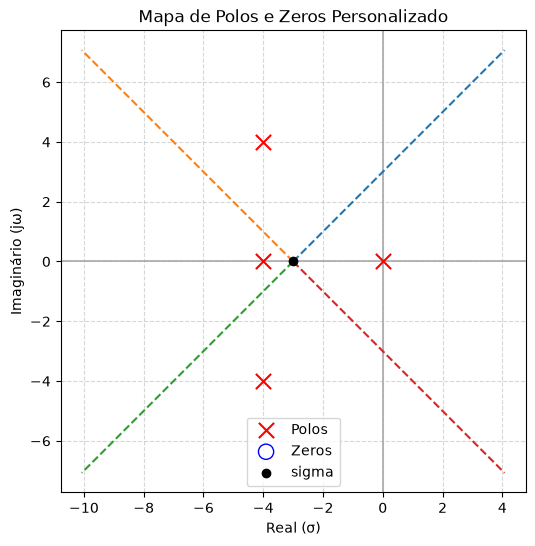

In [42]:
ax = grafico_base()

plot_assintotas(ax, (sigma, 0), angulos_assintotas, 10)
plt.show()

## Passo 08 - Ponto de saída sobre o eixo real

## Passo 09 - Usar Routh-Hurwirtz para determinar cruzamento com eixo imaginário

## Passo 10 - Ângulo de partida para polos complexos e ângulo de chegada para zeros complexos